# Backtesting First Principles: From Returns to Portfolio Simulation

**Docker image**: `ml4t`

## Purpose
Build a complete portfolio simulator from scratch — no frameworks, just NumPy and pandas —
to make every protocol decision in an ETF momentum backtest explicit. Working through the
fundamental equation, transaction costs, and position accounting builds the intuition needed
to interpret (and debug) framework results in later notebooks.

## Learning Objectives
- Apply the fundamental backtest equation `portfolio_return = weights @ asset_returns`.
- Build a bar-by-bar simulator that tracks shares, cash, and transaction costs.
- Compare a regime-aware momentum strategy to a static 60/40 benchmark.
- Evaluate the result against pre-specified term-sheet criteria.

## Book reference
Chapter 16 §16.2 (protocol specification) and §16.4 (the non-ML baseline as yardstick).

## Prerequisites
- Ch6 strategy term sheet conventions (universe, signals, regime, costs).
- Familiarity with pandas time-series indexing and `pct_change`.

## Case study: ETF rotational momentum
- Universe: 10 liquid asset-class ETFs.
- Signal: 6-month risk-adjusted momentum (`cumulative_return / realized_volatility`),
  computed at each month-end close.

- Execution timing: weights take effect on the *first trading day of the
  following month* (a one-bar shift of the signal). See §16.2 — same-bar
  close-to-close execution would be a lookahead error.
- Regime filter: 10Y-2Y Treasury spread > 0.5% → risk-on.
- Risk-on: equal-weight top 3 momentum ETFs. Risk-off: 60% AGG / 40% TLT.
- Rebalancing: end of each calendar month, at the close.
- Transaction costs: 5 bps per trade.

## Success criteria (term sheet)
- Sharpe ratio > 0.5
- Max drawdown < 25%
- Outperform a static 60/40 (60% SPY / 40% AGG) benchmark

## 1. Setup and Configuration

In [1]:
"""Backtesting First Principles — build a portfolio simulator from scratch with NumPy/Pandas."""

# Standard library
import warnings

warnings.filterwarnings("ignore")

# Core data libraries
import numpy as np
import pandas as pd

# Visualization
import plotly.graph_objects as go
import polars as pl
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from plotly.subplots import make_subplots

# Standard imports from utils
from data import load_etfs, load_macro

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all

## 1. Define Universe and Parameters

In [3]:
# ETF Universe - Asset Class Representatives
ETF_UNIVERSE = {
    "SPY": "US Large Cap Equity",
    "QQQ": "US Tech Equity",
    "IWM": "US Small Cap Equity",
    "EFA": "Developed Int'l Equity",
    "EEM": "Emerging Markets Equity",
    "AGG": "US Aggregate Bonds",
    "TLT": "US Long Treasury",
    "GLD": "Gold",
    "VNQ": "US Real Estate",
    "DBC": "Commodities",
}

ETF_SYMBOLS = list(ETF_UNIVERSE.keys())

In [4]:
# Strategy Parameters
LOOKBACK_PERIOD = 126  # 6 months of trading days
MOMENTUM_WINDOW = 126  # For volatility calculation
TOP_N = 3  # Number of ETFs to hold in Risk-On
REGIME_THRESHOLD = 0.005  # 0.5% yield curve slope for Risk-On
REBALANCE_FREQ = "ME"  # Monthly rebalancing

# Backtest Parameters
START_DATE = "2010-01-01"
END_DATE = "2024-01-01"
INITIAL_CASH = 100_000
FEES = 0.0005  # 5 bps per trade

## 2. Data Acquisition

In [5]:
# Load ETF price data via canonical loader
etf_pl = load_etfs()

# Filter to universe and date range
etf_pl = etf_pl.filter(
    (pl.col("symbol").is_in(ETF_SYMBOLS))
    & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
    & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_date())
)

# Pivot to wide format (symbols as columns)
close_prices_pl = etf_pl.pivot(on="symbol", index="timestamp", values="close").sort("timestamp")

# Convert to pandas for simulation (pandas used for portfolio simulation logic)
close_prices = close_prices_pl.to_pandas()
close_prices.set_index("timestamp", inplace=True)

# Ensure all symbols are present
available_symbols = [s for s in ETF_SYMBOLS if s in close_prices.columns]
close_prices = close_prices[available_symbols]

print(f"Loaded {len(close_prices):,} daily bars for {len(available_symbols)} symbols")
print(f"Date range: {close_prices.index.min()} to {close_prices.index.max()}")

Loaded 3,522 daily bars for 10 symbols
Date range: 2010-01-04 00:00:00 to 2023-12-29 00:00:00


In [6]:
# Check for missing data
missing = close_prices.isna().sum()
if missing.sum() > 0:
    print("\nMissing data per ETF:")
    print(missing[missing > 0])

# Forward fill missing values (ETFs have different inception dates)
close_prices = close_prices.ffill()

# Update ETF_SYMBOLS to available symbols
ETF_SYMBOLS = available_symbols

In [7]:
close_prices.tail()

,SPY,QQQ,IWM,EFA,EEM,AGG,TLT,GLD,VNQ,DBC
timestamp,,,,,,,,,,
2023-12-22,460.964417,403.198212,196.573227,69.959579,37.554218,90.694717,89.561966,190.270004,80.313492,20.416229
2023-12-26,462.910828,405.666504,199.129471,70.277870,37.849838,90.878227,89.816628,191.720001,80.908676,20.618279
2023-12-27,463.747833,406.492340,199.831894,70.652344,38.069180,91.456375,91.408150,192.589996,81.302414,20.526438
2023-12-28,463.923004,406.294769,199.070862,70.465103,38.364803,91.254494,90.744255,191.470001,81.879295,20.351940
2023-12-29,462.579987,404.536377,195.821976,70.540001,38.345737,91.080116,89.925743,191.169998,80.908676,20.241732


## 3. Fetch Yield Curve Data for Regime Filter

In [8]:
# Load yield curve from macro data
macro_df = load_macro()

if "YIELD_CURVE_SLOPE" in macro_df.columns:
    yield_curve_pl = macro_df.select(
        [pl.col("timestamp"), (pl.col("YIELD_CURVE_SLOPE") / 100).alias("slope")]
    ).drop_nulls()
    print("Loaded yield curve from local macro data (YIELD_CURVE_SLOPE)")
else:
    yield_curve_pl = macro_df.select(
        [pl.col("timestamp"), ((pl.col("dgs10") - pl.col("dgs2")) / 100).alias("slope")]
    ).drop_nulls()
    print("Computed yield curve from local macro data (dgs10 - dgs2)")

yield_curve_pd = yield_curve_pl.to_pandas().set_index("timestamp")

Loaded yield curve from local macro data (YIELD_CURVE_SLOPE)


In [9]:
# Align yield curve to price data
yield_curve_aligned = yield_curve_pd.reindex(close_prices.index, method="ffill")

# Define regime: Risk-On when slope > 0.5%
regime = (yield_curve_aligned["slope"] > REGIME_THRESHOLD).astype(int)

print("\nRegime Distribution:")
print(f"  Risk-On days:  {regime.sum():,} ({regime.mean() * 100:.1f}%)")
print(f"  Risk-Off days: {(~regime.astype(bool)).sum():,} ({(1 - regime.mean()) * 100:.1f}%)")


Regime Distribution:
  Risk-On days:  2,495 (70.8%)
  Risk-Off days: 1,027 (29.2%)


## 4. Compute Risk-Adjusted Momentum

In [10]:
# Calculate returns
daily_returns = close_prices.pct_change()

# Calculate 6-month cumulative return
cumulative_return = close_prices.pct_change(LOOKBACK_PERIOD)

# Calculate 6-month realized volatility (annualized)
realized_vol = daily_returns.rolling(LOOKBACK_PERIOD).std() * np.sqrt(252)

# Risk-adjusted momentum = cumulative return / realized volatility
momentum_score = cumulative_return / realized_vol

Momentum scores (most recent five trading days):

In [11]:
momentum_score.tail().round(3)

,SPY,QQQ,IWM,EFA,EEM,AGG,TLT,GLD,VNQ,DBC
timestamp,,,,,,,,,,
2023-12-22,0.905,0.908,0.630,0.493,0.136,0.322,-0.142,0.550,0.538,0.115
2023-12-26,0.847,0.838,0.623,0.461,0.121,0.375,-0.114,0.658,0.512,0.304
2023-12-27,0.860,0.839,0.615,0.497,0.200,0.419,-0.046,0.720,0.531,0.294
2023-12-28,0.827,0.850,0.530,0.487,0.288,0.500,0.010,0.675,0.509,0.228
2023-12-29,0.696,0.716,0.409,0.401,0.232,0.441,-0.097,0.603,0.411,0.130


In [12]:
# Rank ETFs by momentum (1 = highest momentum)
momentum_rank = momentum_score.rank(axis=1, ascending=False)

## 5. Generate Portfolio Weights

Strategy Logic:
- **Risk-On Regime**: Equal-weight top 3 momentum ETFs (33.3% each)
- **Risk-Off Regime**: 60% AGG + 40% TLT (defensive positioning)

In [13]:
# Initialize weights DataFrame with NaN (so ffill works correctly)
weights = pd.DataFrame(np.nan, index=close_prices.index, columns=ETF_SYMBOLS)

# Generate rebalancing dates (last trading day of each month)
# Note: resample().last().index gives calendar month-end which may not be trading days
# Instead, use the actual last trading day index from each month
rebalance_dates = close_prices.loc[
    close_prices.index.isin(
        close_prices.groupby(close_prices.index.to_period("M")).apply(lambda x: x.index[-1])
    )
].index
print(f"Rebalance dates: {len(rebalance_dates)} monthly rebalances")

Rebalance dates: 168 monthly rebalances


In [14]:
# Compute weights at each rebalancing date
# First, find when momentum data becomes available (after lookback warm-up)
first_valid_momentum = momentum_rank.dropna(how="all").index[0]
print(f"First valid momentum date: {first_valid_momentum}")

# Set initial allocation on day 1 (before first rebalance date)
# Use 60/40 as default since we don't have momentum data yet
first_day = close_prices.index[0]
weights.loc[first_day, :] = 0.0  # Zero out all
weights.loc[first_day, "AGG"] = 0.60
weights.loc[first_day, "TLT"] = 0.40

for i, date in enumerate(rebalance_dates):
    # Set all weights for this row (explicit zeros for non-held assets)
    weights.loc[date, :] = 0.0

    # Before momentum data is available, use default 60/40 allocation
    if date < first_valid_momentum:
        weights.loc[date, "AGG"] = 0.60
        weights.loc[date, "TLT"] = 0.40
        continue

    if date not in momentum_rank.index:
        # Dates where momentum data isn't available - use 60/40
        weights.loc[date, "AGG"] = 0.60
        weights.loc[date, "TLT"] = 0.40
        continue

    # Get regime on this date
    is_risk_on = regime.loc[date] == 1

    if is_risk_on:
        # Risk-On: Top 3 momentum ETFs, equal weight
        ranks = momentum_rank.loc[date]
        top_n_etfs = ranks[ranks <= TOP_N].index.tolist()

        # Equal weight among top N
        weight = 1.0 / len(top_n_etfs) if len(top_n_etfs) > 0 else 0
        for etf in top_n_etfs:
            weights.loc[date, etf] = weight
    else:
        # Risk-Off: 60% AGG, 40% TLT
        weights.loc[date, "AGG"] = 0.60
        weights.loc[date, "TLT"] = 0.40

# Forward fill weights to all trading days; this gives target weights as of
# each month-end close.
weights = weights.ffill()

# Shift target weights forward by one trading day so the signal computed at
# the month-end close *executes* on the first trading day of the next month.
# This matches §16.2's close-to-next-open execution convention (we use close
# prices throughout, so "next bar" is the next trading day's close). Without
# this shift the simulator would trade at the same close used to compute the
# signal — same-bar execution that the chapter explicitly rules out.
weights = weights.shift(1)
# Re-seed the first bar with a neutral 60/40 since the shift removed it.
weights.iloc[0] = 0.0
weights.iloc[0, weights.columns.get_loc("AGG")] = 0.60
weights.iloc[0, weights.columns.get_loc("TLT")] = 0.40
weights = weights.ffill()

First valid momentum date: 2010-07-06 00:00:00


In [15]:
# Verify weights sum to ~1
weight_sums = weights.sum(axis=1)
print("Weight sum statistics:")
print(f"  Mean: {weight_sums.mean():.4f}")
print(f"  Min:  {weight_sums.min():.4f}")
print(f"  Max:  {weight_sums.max():.4f}")

Weight sum statistics:
  Mean: 1.0000
  Min:  1.0000
  Max:  1.0000


## 6. Visualize Regime and Positioning

In [16]:
# Sample positioning over time
fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    row_heights=[0.4, 0.3, 0.3],
    subplot_titles=["Yield Curve Slope", "Regime (1=Risk-On)", "Portfolio Weights"],
)

# Yield curve slope
fig.add_trace(
    go.Scatter(
        x=yield_curve_aligned.index,
        y=yield_curve_aligned["slope"] * 100,
        name="10Y-2Y Spread",
        line=dict(color="blue"),
    ),
    row=1,
    col=1,
)
fig.add_hline(y=REGIME_THRESHOLD * 100, line_dash="dash", line_color="red", row=1, col=1)

# Regime
fig.add_trace(
    go.Scatter(x=regime.index, y=regime, name="Risk-On", line=dict(color="green")), row=2, col=1
)

# Weights (stacked area for top holdings)
for etf in ETF_SYMBOLS:
    fig.add_trace(
        go.Scatter(x=weights.index, y=weights[etf], name=etf, stackgroup="weights", mode="lines"),
        row=3,
        col=1,
    )

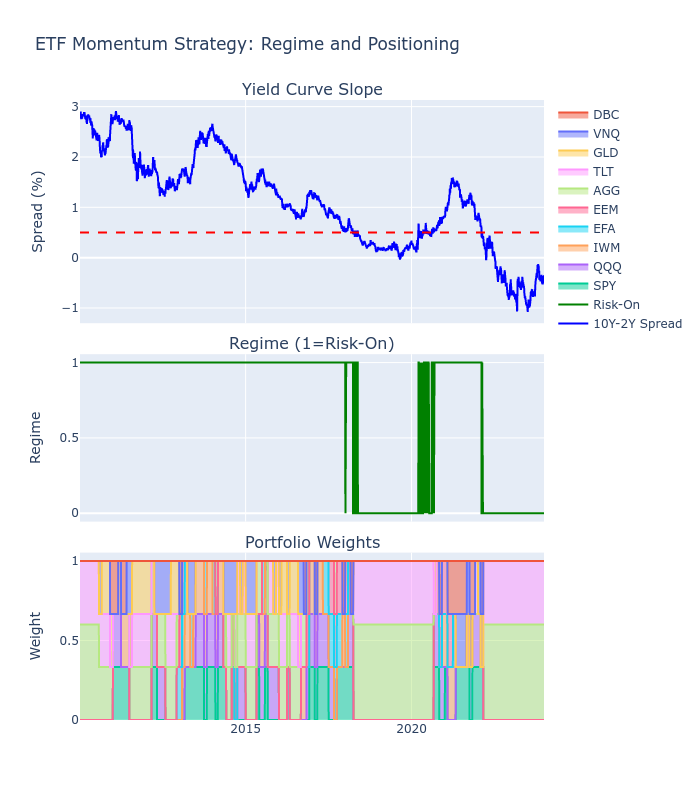

In [17]:
# Layout and display
fig.update_layout(
    height=800,
    title="ETF Momentum Strategy: Regime and Positioning",
    showlegend=True,
    yaxis_title="Spread (%)",
    yaxis2_title="Regime",
    yaxis3_title="Weight",
)
fig.show()

## 7. The Fundamental Equation

Before building a full simulator, understand the core math:

```
portfolio_return[t] = sum(weights[t-1] * asset_returns[t])
```

Or in matrix form: `portfolio_return = (weights.shift(1) * returns).sum(axis=1)`

This is **vectorized backtesting** - fast but ignores:
- Transaction costs (turnover-dependent)
- Position limits (leverage, concentration)
- Execution timing (open vs close fills)

For production strategies, you need a bar-by-bar simulator.

In [18]:
# Pure vectorized approach (no costs, no position tracking)
vectorized_returns = (weights.shift(1) * daily_returns).sum(axis=1).dropna()
vectorized_equity = (1 + vectorized_returns).cumprod() * INITIAL_CASH
print(f"Vectorized (no costs) final value: ${vectorized_equity.iloc[-1]:,.2f}")

Vectorized (no costs) final value: $283,842.76


## 8. Bar-by-Bar Simulation

For realistic backtesting, we simulate bar-by-bar to capture:
- Transaction costs proportional to trade value
- Cash management (invest available cash)
- Position tracking (shares held)

In [19]:
# Manual simulation for multi-asset rebalancing
def simulate_portfolio(prices, weights, initial_cash, fees):
    """
    Simulate portfolio with target weight rebalancing.

    Parameters
    ----------
    prices : pd.DataFrame
        Daily close prices (rows=dates, cols=assets)
    weights : pd.DataFrame
        Target weights (rows=dates, cols=assets)
    initial_cash : float
        Starting capital
    fees : float
        Transaction cost as fraction

    Returns
    -------
    pd.Series
        Portfolio value over time
    """
    n_days = len(prices)
    portfolio_value = np.zeros(n_days)
    holdings = pd.Series(0.0, index=prices.columns)  # Number of shares
    cash = initial_cash

    # Get rebalancing dates (when weights change)
    weight_changes = weights.diff().abs().sum(axis=1)
    rebalance_dates = weight_changes[weight_changes > 0.01].index

    # CRITICAL: Always include first date to establish initial positions
    # (fixes benchmark showing 0% when weights are static)
    first_date = prices.index[0]
    if first_date not in rebalance_dates:
        rebalance_dates = rebalance_dates.insert(0, first_date)

    for i, date in enumerate(prices.index):
        # Current prices
        current_prices = prices.loc[date]

        # Portfolio value before any trades
        holdings_value = (holdings * current_prices).sum()
        total_value = cash + holdings_value
        portfolio_value[i] = total_value

        # Check if rebalancing needed
        if date in rebalance_dates:
            target_weights = weights.loc[date]

            # Target holdings in dollars
            target_values = target_weights * total_value

            # Current holdings in dollars
            current_values = holdings * current_prices

            # Trade amounts
            trade_values = target_values - current_values

            # Execute trades with costs
            for asset in prices.columns:
                trade_value = trade_values[asset]
                if abs(trade_value) > 1:  # Minimum trade threshold
                    # Pay transaction cost
                    trade_cost = abs(trade_value) * fees
                    cash -= trade_cost

                    # Update holdings
                    shares_traded = trade_value / current_prices[asset]
                    holdings[asset] += shares_traded
                    cash -= trade_value

    return pd.Series(portfolio_value, index=prices.index)

In [20]:
# Run simulation
portfolio_value = simulate_portfolio(close_prices, weights, INITIAL_CASH, FEES)

# Calculate returns
portfolio_returns = portfolio_value.pct_change().dropna()

In [21]:
print(f"Final Portfolio Value: ${portfolio_value.iloc[-1]:,.2f}")
print(f"Total Return: {(portfolio_value.iloc[-1] / INITIAL_CASH - 1) * 100:.2f}%")

Final Portfolio Value: $271,405.87
Total Return: 171.41%


## 9. Create Benchmark: 60/40 Portfolio

In [22]:
# 60/40 benchmark weights (static)
benchmark_weights = pd.DataFrame(0.0, index=close_prices.index, columns=ETF_SYMBOLS)
benchmark_weights["SPY"] = 0.60  # 60% equity (SPY as proxy)
benchmark_weights["AGG"] = 0.40  # 40% bonds

# Simulate benchmark
benchmark_value = simulate_portfolio(close_prices, benchmark_weights, INITIAL_CASH, FEES)
benchmark_returns = benchmark_value.pct_change().dropna()

## 10. Performance Comparison

In [23]:
# Calculate metrics manually
def calculate_metrics(returns, periods_per_year=252):
    """Calculate key performance metrics."""
    total_return = (1 + returns).prod() - 1
    annual_return = (1 + total_return) ** (periods_per_year / len(returns)) - 1
    annual_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = annual_return / annual_vol if annual_vol > 0 else 0

    # Sortino (downside deviation)
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(periods_per_year)
    sortino = annual_return / downside_vol if downside_vol > 0 else 0

    # Max drawdown
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.expanding().max()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_dd = drawdown.min()

    # Calmar
    calmar = annual_return / abs(max_dd) if max_dd != 0 else 0

    return {
        "Total Return (%)": total_return * 100,
        "Annual Return (%)": annual_return * 100,
        "Annual Volatility (%)": annual_vol * 100,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown (%)": max_dd * 100,
        "Calmar Ratio": calmar,
    }

In [24]:
# Compare strategies
strategy_metrics = calculate_metrics(portfolio_returns)
benchmark_metrics = calculate_metrics(benchmark_returns)

comparison = pd.DataFrame(
    {"ETF Momentum": strategy_metrics, "60/40 Benchmark": benchmark_metrics}
).T

print("\n" + "=" * 70)
print("PERFORMANCE COMPARISON")
print("=" * 70)
comparison.round(3)


PERFORMANCE COMPARISON


,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio
ETF Momentum,171.406,7.407,11.357,0.652,0.857,-31.860,0.233
60/40 Benchmark,282.773,10.083,12.656,0.797,0.960,-26.903,0.375


## 11. Success Criteria Evaluation

In [25]:
# From Term Sheet success criteria
print("\n" + "=" * 70)
print("SUCCESS CRITERIA EVALUATION")
print("=" * 70)

criteria = {
    "Sharpe Ratio > 0.5": strategy_metrics["Sharpe Ratio"] > 0.5,
    "Max Drawdown < 25%": abs(strategy_metrics["Max Drawdown (%)"]) < 25,
    "Outperform 60/40": strategy_metrics["Total Return (%)"]
    > benchmark_metrics["Total Return (%)"],
}

for criterion, passed in criteria.items():
    status = "[OK] PASS" if passed else "[FAIL] FAIL"
    print(f"  {criterion}: {status}")

all_passed = all(criteria.values())
print(
    f"\nOverall: {'GO - Strategy meets all criteria' if all_passed else 'NO-GO - Review strategy'}"
)


SUCCESS CRITERIA EVALUATION
  Sharpe Ratio > 0.5: [OK] PASS
  Max Drawdown < 25%: [FAIL] FAIL
  Outperform 60/40: [FAIL] FAIL

Overall: NO-GO - Review strategy


**Interpretation**: The strategy fails 2 of 3 criteria. This is not a failure of the
backtesting methodology — it is the *expected* outcome at this stage. A simple
momentum strategy with a single regime filter and equal weighting is a starting point,
not a finished product. The remaining chapters build on this baseline:

- **Ch17** (Portfolio Construction): Optimize weights beyond equal-weight
- **Ch18** (Transaction Costs): Model realistic costs beyond flat 5 bps
- **Ch19** (Risk Management): Add drawdown controls and position limits
- **Ch20** (Synthesis): Combine multiple signals and strategies

The honest NO-GO result here is more instructive than a cherry-picked backtest that
passes all criteria. It demonstrates that backtesting infrastructure must be built
*before* you know whether the strategy works.

## 12. Visualize Results

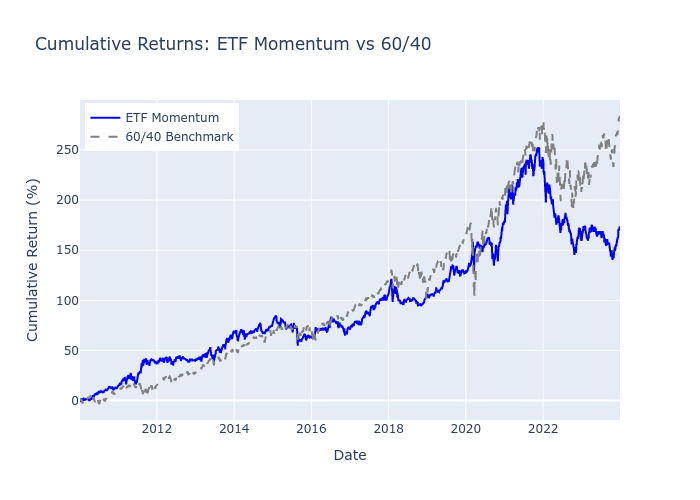

In [26]:
# Cumulative returns comparison
fig = go.Figure()

strategy_cum = (portfolio_value / INITIAL_CASH - 1) * 100
benchmark_cum = (benchmark_value / INITIAL_CASH - 1) * 100

fig.add_trace(
    go.Scatter(
        x=portfolio_value.index,
        y=strategy_cum,
        name="ETF Momentum",
        line=dict(color="blue", width=2),
    )
)

fig.add_trace(
    go.Scatter(
        x=benchmark_value.index,
        y=benchmark_cum,
        name="60/40 Benchmark",
        line=dict(color="gray", dash="dash"),
    )
)

fig.update_layout(
    title="Cumulative Returns: ETF Momentum vs 60/40",
    xaxis_title="Date",
    yaxis_title="Cumulative Return (%)",
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.show()

### Drawdown Helper

Compute percentage drawdown from the running peak.

In [27]:
def compute_drawdown(values):
    rolling_max = values.expanding().max()
    return (values - rolling_max) / rolling_max * 100

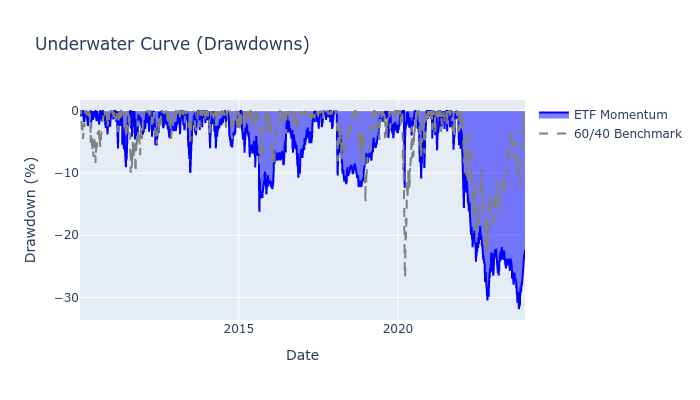

In [28]:
# Drawdown comparison
strategy_dd = compute_drawdown(portfolio_value)
benchmark_dd = compute_drawdown(benchmark_value)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=strategy_dd.index,
        y=strategy_dd,
        name="ETF Momentum",
        fill="tozeroy",
        line=dict(color="blue"),
    )
)

fig.add_trace(
    go.Scatter(
        x=benchmark_dd.index,
        y=benchmark_dd,
        name="60/40 Benchmark",
        line=dict(color="gray", dash="dash"),
    )
)

fig.update_layout(
    title="Underwater Curve (Drawdowns)", xaxis_title="Date", yaxis_title="Drawdown (%)", height=400
)
fig.show()

## 13. Regime-Conditional Performance

In [29]:
# Analyze performance by regime
regime_aligned = regime.reindex(portfolio_returns.index)

risk_on_returns = portfolio_returns[regime_aligned == 1]
risk_off_returns = portfolio_returns[regime_aligned == 0]

print("\n" + "=" * 70)
print("REGIME-CONDITIONAL PERFORMANCE")
print("=" * 70)

print("\nRisk-On Periods:")
print(f"  Days: {len(risk_on_returns):,}")
print(f"  Mean Daily Return: {risk_on_returns.mean() * 100:.4f}%")
print(f"  Volatility (ann.): {risk_on_returns.std() * np.sqrt(252) * 100:.2f}%")

print("\nRisk-Off Periods:")
print(f"  Days: {len(risk_off_returns):,}")
print(f"  Mean Daily Return: {risk_off_returns.mean() * 100:.4f}%")
print(f"  Volatility (ann.): {risk_off_returns.std() * np.sqrt(252) * 100:.2f}%")


REGIME-CONDITIONAL PERFORMANCE

Risk-On Periods:
  Days: 2,494
  Mean Daily Return: 0.0369%
  Volatility (ann.): 11.79%

Risk-Off Periods:
  Days: 1,027
  Mean Daily Return: 0.0164%
  Volatility (ann.): 10.22%


## 14. Evaluate with ml4t-diagnostic

In [30]:
# Align returns with benchmark on common dates
common_idx = portfolio_returns.index.intersection(benchmark_returns.index)
aligned_returns = portfolio_returns.loc[common_idx].values
aligned_benchmark = benchmark_returns.loc[common_idx].values

if len(aligned_returns) == 0 or len(aligned_benchmark) == 0:
    raise ValueError("Insufficient aligned data for ml4t-diagnostic analysis")

analysis = PortfolioAnalysis(
    returns=aligned_returns,
    benchmark=aligned_benchmark,
    dates=common_idx,
    periods_per_year=252,
)
metrics = analysis.compute_summary_stats()

print("\n" + "=" * 70)
print("ML4T DIAGNOSTIC - COMPREHENSIVE EVALUATION")
print("=" * 70)
print(metrics.summary())


ML4T DIAGNOSTIC - COMPREHENSIVE EVALUATION
Portfolio Performance Summary

Returns
------------------------------
  Total Return:           171.41%
  Annual Return:            7.41%
  Annual Volatility:       11.36%

Risk-Adjusted Returns
------------------------------
  Sharpe Ratio:             0.686
  Sortino Ratio:            0.645
  Calmar Ratio:             0.233
  Omega Ratio:              1.128
  Tail Ratio:               0.993

Risk Metrics
------------------------------
  Max Drawdown:           -31.86%
  VaR (95%):               -1.13%
  CVaR (95%):              -1.73%

Distribution
------------------------------
  Skewness:                -0.466
  Kurtosis:                 4.053
  Stability (R²):           0.859

Win/Loss
------------------------------
  Win Rate:                54.62%
  Profit Factor:             1.13
  Avg Win:                  0.50%
  Avg Loss:                -0.53%

Benchmark Comparison
------------------------------
  Alpha (annual):           5.14%
  

## Key Takeaways

1. **The fundamental equation governs everything.** Portfolio return is the
   inner product of yesterday's weights and today's asset returns. The bar-by-bar
   simulator above is just that equation extended to track shares, cash, and
   transaction costs explicitly.
2. **The baseline does not beat the static 60/40 in this sample.** With a
   Sharpe of 0.65 against the benchmark's 0.80 and a deeper max drawdown
   (−31.9% vs −26.9%), the strategy passes only one of three term-sheet
   criteria. That is the intended outcome: a transparent baseline that any
   later ML strategy must improve on.
3. **The regime filter does not reduce drawdowns here.** The 10Y-2Y spread
   splits the sample roughly 71/29 (risk-on/risk-off) but the strategy's worst
   drawdown still occurs in this period — a reminder that simple regime
   indicators are not a substitute for risk management.
4. **Transaction costs are visible already at 5 bps.** With monthly
   rebalancing the cost drag is small but non-zero; once Ch18 introduces
   realistic cost models, this baseline becomes the reference point against
   which more sophisticated execution is measured.

**Next**: `03_single_asset_vectorbt` and `04_single_asset_ml4t_backtest` re-run
the same strategy through two production-grade engines, and `06_framework_parity`
reconciles the differences. See chapter §16.4 for the baseline as a yardstick.